In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Personal\Capstone project\Capstone project\final_storm_data.csv")

C:\Users\naman\AppData\Local\Temp\ipykernel_10168\935824698.py:3: DtypeWarning: Columns (16,25,26,28,29,34,35,37,39,40,42,43,48,49,55,56,68,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Personal\Capstone project\Capstone project\final_storm_data.csv")


In [145]:
t = df[(df["event_type"] == "Thunderstorm Wind") & (df["magnitude"] <=30)].iloc[5].to_dict()
t

{'begin_yearmonth': 202402,
 'begin_day': 4,
 'begin_time': 1709,
 'end_yearmonth': 202402,
 'end_day': 4,
 'end_time': 1709,
 'episode_id_x': 187979.0,
 'event_id': 1154905,
 'state': 'CALIFORNIA',
 'state_fips': 6.0,
 'year': 2024,
 'month_name': 'February',
 'event_type': 'Thunderstorm Wind',
 'cz_type': 'C',
 'cz_fips': 81,
 'cz_name': 'SAN MATEO',
 'wfo': 'MTR',
 'begin_date_time': '04-FEB-24 17:09:00',
 'cz_timezone': 'PST-8',
 'end_date_time': '04-FEB-24 17:09:00',
 'injuries_direct': 0,
 'injuries_indirect': 0,
 'deaths_direct': 0,
 'deaths_indirect': 0,
 'damage_property': '0.01K',
 'damage_crops': '0.00K',
 'source': 'Public',
 'magnitude': 26.0,
 'magnitude_type': 'EG',
 'flood_cause': nan,
 'category': nan,
 'tor_f_scale': nan,
 'tor_length': nan,
 'tor_width': nan,
 'tor_other_wfo': nan,
 'tor_other_cz_state': nan,
 'tor_other_cz_fips': nan,
 'tor_other_cz_name': nan,
 'begin_range': 1.0,
 'begin_azimuth': 'NE',
 'begin_location': 'SAN CARLOS',
 'end_range': 1.0,
 'end_azi

In [146]:
from datetime import datetime, timedelta
import pandas as pd
import openmeteo_requests
import requests_cache
from retry_requests import retry

# Initialize caching and retry mechanisms
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# User-specified parameters
latitude = t["latitude"]
longitude = t["longitude"]
end_date_time = t["end_date_time"]
cz_timezone = 'CST-6'  # Central Standard Time (UTC-6)

# Convert end_date_time to UTC and calculate start_date_time (72 hours before)
end_date_utc = datetime.strptime(end_date_time, '%d-%b-%y %H:%M:%S') - timedelta(hours=8) + timedelta(hours=50) # CST to UTC conversion
start_date_utc = end_date_utc - timedelta(hours=72)

# Prepare parameters for the API request
params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date_utc.strftime('%Y-%m-%d'),
    "end_date": end_date_utc.strftime('%Y-%m-%d'),
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "dew_point_2m",
        "apparent_temperature",
        "precipitation",
        "rain",
        "snowfall",
        "snow_depth",
        "weather_code",
        "pressure_msl",
        "surface_pressure",
        "cloud_cover",
        "wind_speed_10m",
        "wind_direction_10m",
        "wind_gusts_10m",
        "soil_temperature_0_to_7cm",
        "soil_moisture_0_to_7cm"
    ]
}

# Fetch data from Open-Meteo API
responses = openmeteo.weather_api(
    "https://archive-api.open-meteo.com/v1/archive",
    params=params
)
response = responses[0]

# Process hourly data from the response
hourly = response.Hourly()
data = {
    "date": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ),
    "latitude": latitude,
    "longitude": longitude
}

# Add all weather variables to the data dictionary
for idx, var in enumerate(params["hourly"]):
    data[var] = hourly.Variables(idx).ValuesAsNumpy()

# Convert the data dictionary into a DataFrame for further analysis or saving
weather_data_df = pd.DataFrame(data)

# Display or save the DataFrame as needed
# print(weather_data_df)


In [137]:
weather_data_df["wind_gusts_10m"].max()

np.float32(68.4)

In [139]:
weather_data_df.columns

Index(['date', 'latitude', 'longitude', 'temperature_2m',
       'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature',
       'precipitation', 'rain', 'snowfall', 'snow_depth', 'weather_code',
       'pressure_msl', 'surface_pressure', 'cloud_cover', 'wind_speed_10m',
       'wind_direction_10m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm',
       'soil_moisture_0_to_7cm'],
      dtype='object')

<Axes: title={'center': 'Wind Gusts (10m)'}, xlabel='Date', ylabel='Wind Gusts (m/s)'>

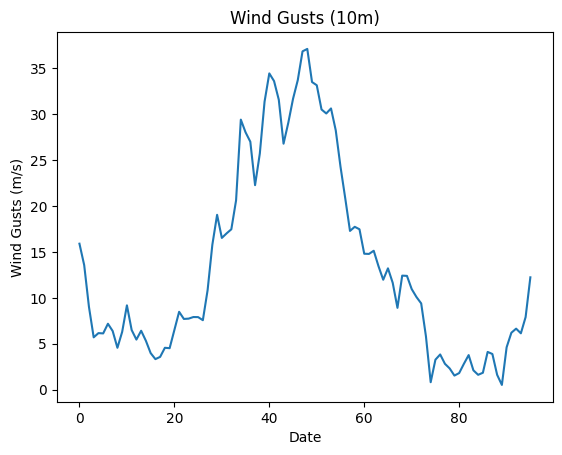

In [147]:
# create a line chart
weather_data_df["wind_speed_10m"].plot(title="Wind Gusts (10m)", xlabel="Date", ylabel="Wind Gusts (m/s)")

<Axes: title={'center': 'Wind Gusts (10m)'}, xlabel='Date', ylabel='Wind Gusts (m/s)'>

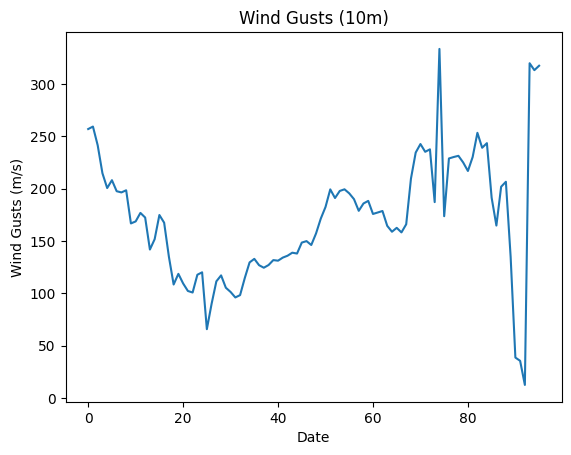

In [148]:
# create a line chart
weather_data_df["wind_direction_10m"].plot(title="Wind Gusts (10m)", xlabel="Date", ylabel="Wind Gusts (m/s)")

<Axes: title={'center': 'Wind Gusts (10m)'}, xlabel='Date', ylabel='Wind Gusts (m/s)'>

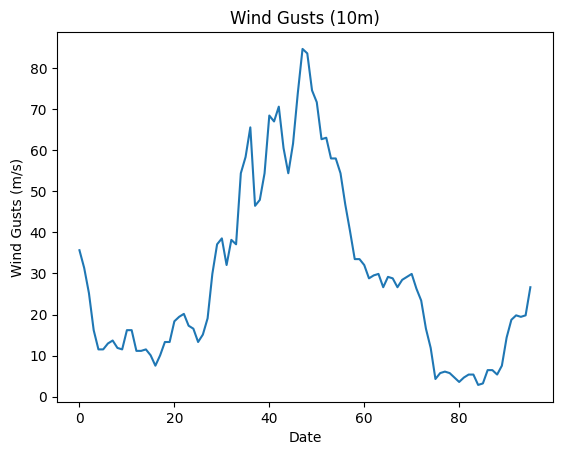

In [149]:
# create a line chart
weather_data_df["wind_gusts_10m"].plot(title="Wind Gusts (10m)", xlabel="Date", ylabel="Wind Gusts (m/s)")

Event Local End Time: 2024-02-27 19:39:00-06:00
Fetching Data Window (UTC): 2024-02-25 01:39:00+00:00 to 2024-02-28 01:39:00+00:00
Event Local End Time: 2024-06-10 14:02:00-05:00
Fetching Data Window (UTC): 2024-06-07 19:02:00+00:00 to 2024-06-10 19:02:00+00:00


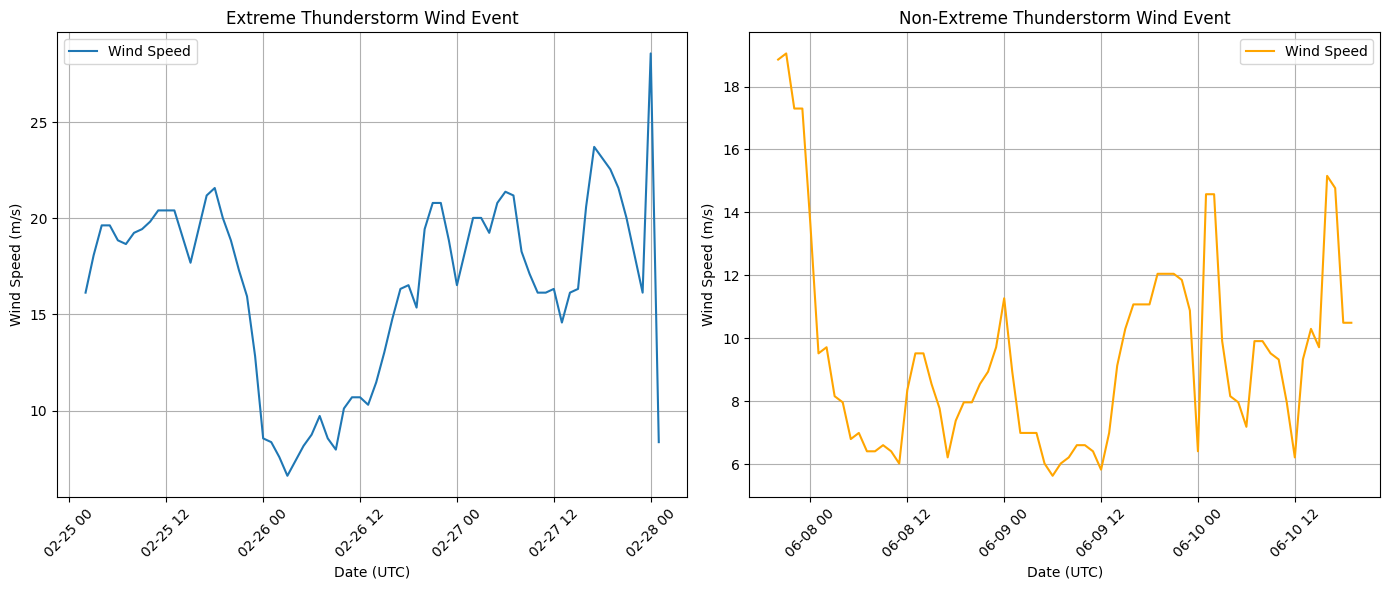

In [172]:
from datetime import datetime, timedelta, timezone
import pandas as pd
import matplotlib.pyplot as plt
import openmeteo_requests
import requests_cache
from retry_requests import retry
import numpy as np

# ---------------------------
# Setup caching and Open-Meteo client
# ---------------------------
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# ---------------------------
# Load NOAA Dataset
# ---------------------------
# Replace 'noaa_data.csv' with the path to your NOAA dataset CSV file.
# df = pd.read_csv("noaa_data.csv")

# ---------------------------
# Filter for Thunderstorm Wind events
# ---------------------------
extreme = df[(df["event_type"] == "Thunderstorm Wind") & (df["magnitude"] >=70)].iloc[0].to_dict()

non_extreme = df[(df["event_type"] == "Thunderstorm Wind") & (df["magnitude"] <=5)].iloc[5].to_dict()

# ---------------------------
# Helper function to parse timezone from NOAA field
# ---------------------------
def parse_timezone(tz_str):
    """
    Parse a timezone string from NOAA dataset (e.g., "PST-8", "CST-6")
    and return a datetime.timezone object.
    """
    # Check if tz_str contains '-' or '+'
    if '-' in tz_str:
        parts = tz_str.split('-')
        offset = -abs(int(parts[1]))
    elif '+' in tz_str:
        parts = tz_str.split('+')
        offset = abs(int(parts[1]))
    else:
        offset = 0  # default to UTC if not specified
    return timezone(timedelta(hours=offset))

# ---------------------------
# Define a function to fetch weather data for an event
# ---------------------------
def fetch_weather_data(event):
    """
    Given an event dictionary, fetch weather data from Open-Meteo for the 72 hours prior 
    to the event's end_date_time.
    The function converts the local event time (using cz_timezone) to UTC.
    """
    latitude = event["latitude"]
    longitude = event["longitude"]
    end_date_time_str = event["end_date_time"]  # e.g., "04-FEB-24 17:09:00"
    tz_str = event.get("cz_timezone", "UTC")     # default to UTC if not provided

    event_tz = parse_timezone(tz_str)
    
    # Parse the end_date_time in local time and assign the proper timezone
    end_local = datetime.strptime(end_date_time_str, '%d-%b-%y %H:%M:%S').replace(tzinfo=event_tz)
    
    # Convert the local time to UTC - *** REMOVED THE INCORRECT +timedelta(hours=5) ***
    end_date_utc = end_local.astimezone(timezone.utc) 
    
    # Define the start of the window (72 hours prior to the END time)
    start_date_utc = end_date_utc - timedelta(hours=72) 
    
    print(f"Event Local End Time: {end_local}")
    print(f"Fetching Data Window (UTC): {start_date_utc} to {end_date_utc}")

    # Prepare parameters for the API request - Fetch one extra day on end_date
    # because the API end_date is inclusive of the day but we want hourly data up to the specific time.
    # Fetching data up to the *day* of end_date_utc ensures we get the hour of the event.
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date_utc.strftime('%Y-%m-%d'),
        # Fetch data up to and including the day the event ends
        "end_date": end_date_utc.strftime('%Y-%m-%d'), 
        "hourly": [
            "temperature_2m", "relative_humidity_2m", "dew_point_2m", 
            "apparent_temperature", "precipitation", "rain", "snowfall", 
            "snow_depth", "weather_code", "pressure_msl", "surface_pressure", 
            "cloud_cover", "wind_speed_10m", "wind_direction_10m", 
            "wind_gusts_10m", "soil_temperature_0_to_7cm", "soil_moisture_0_to_7cm"
        ],
        "wind_speed_unit": "kn" # Requesting knots
    }
    
    responses = openmeteo.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)
    response = responses[0]
    
    hourly = response.Hourly()
    
    times = pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    )
    
    data = { "date": times }
    # Map response variables directly using the order in params['hourly']
    hourly_variables = params["hourly"]
    for i, var_name in enumerate(hourly_variables):
         data[var_name] = hourly.Variables(i).ValuesAsNumpy()

    weather_df = pd.DataFrame(data)
    
    # Filter the dataframe to the precise 72-hour window ending at the event time
    # because the API might return full days.
    weather_df = weather_df[(weather_df['date'] > start_date_utc) & (weather_df['date'] <= end_date_utc)].copy() # Use > for start to exclude exact start if needed, <= for end
    # Add lat/lon back after filtering if needed, or keep them from the start if preferred
    weather_df["latitude"] = latitude
    weather_df["longitude"] = longitude

    return weather_df

# ---------------------------
# Fetch weather data for extreme and non-extreme events
# ---------------------------
weather_extreme = fetch_weather_data(extreme)
weather_non_extreme = fetch_weather_data(non_extreme)

# ---------------------------
# Plotting the time-series wind speed data for comparison
# ---------------------------
plt.figure(figsize=(14, 6))

# Plot extreme event wind speed
plt.subplot(1, 2, 1)
plt.plot(weather_extreme["date"], weather_extreme["wind_gusts_10m"], label="Wind Speed")
plt.title("Extreme Thunderstorm Wind Event")
plt.xlabel("Date (UTC)")
plt.ylabel("Wind Speed (m/s)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

# Plot non-extreme event wind speed
plt.subplot(1, 2, 2)
plt.plot(weather_non_extreme["date"], weather_non_extreme["wind_gusts_10m"], label="Wind Speed", color='orange')
plt.title("Non-Extreme Thunderstorm Wind Event")
plt.xlabel("Date (UTC)")
plt.ylabel("Wind Speed (m/s)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# ---------------------------
# Additional Analysis
# ---------------------------
# You can add further analysis and visualization (e.g., temperature, humidity) to understand other meteorological factors.


Fetching data for EXTREME event...

Fetching data for event ending:
  End Local: 2024-02-27 19:39:00 UTC-06:00-0600
  End UTC:   2024-02-28 01:39:00 UTC
  Start UTC: 2024-02-25 01:39:00 UTC
  Lat/Lon:   42.1106, -88.0856
  Requesting 32 variables...
  Data received successfully.
  API reported 32 variables returned.
    Processing: temperature_2m (index 0, 96 values)
    Processing: relative_humidity_2m (index 1, 96 values)
    Processing: dew_point_2m (index 2, 96 values)
    Processing: apparent_temperature (index 3, 96 values)
    Processing: pressure_msl (index 4, 96 values)
    Processing: surface_pressure (index 5, 96 values)
    Processing: precipitation (index 6, 96 values)
    Processing: rain (index 7, 96 values)
    Processing: snowfall (index 8, 96 values)
    Processing: weather_code (index 9, 96 values)
    Processing: cloud_cover (index 10, 96 values)
    Processing: wind_speed_10m (index 11, 96 values)
    Processing: wind_direction_10m (index 12, 96 values)
    Process

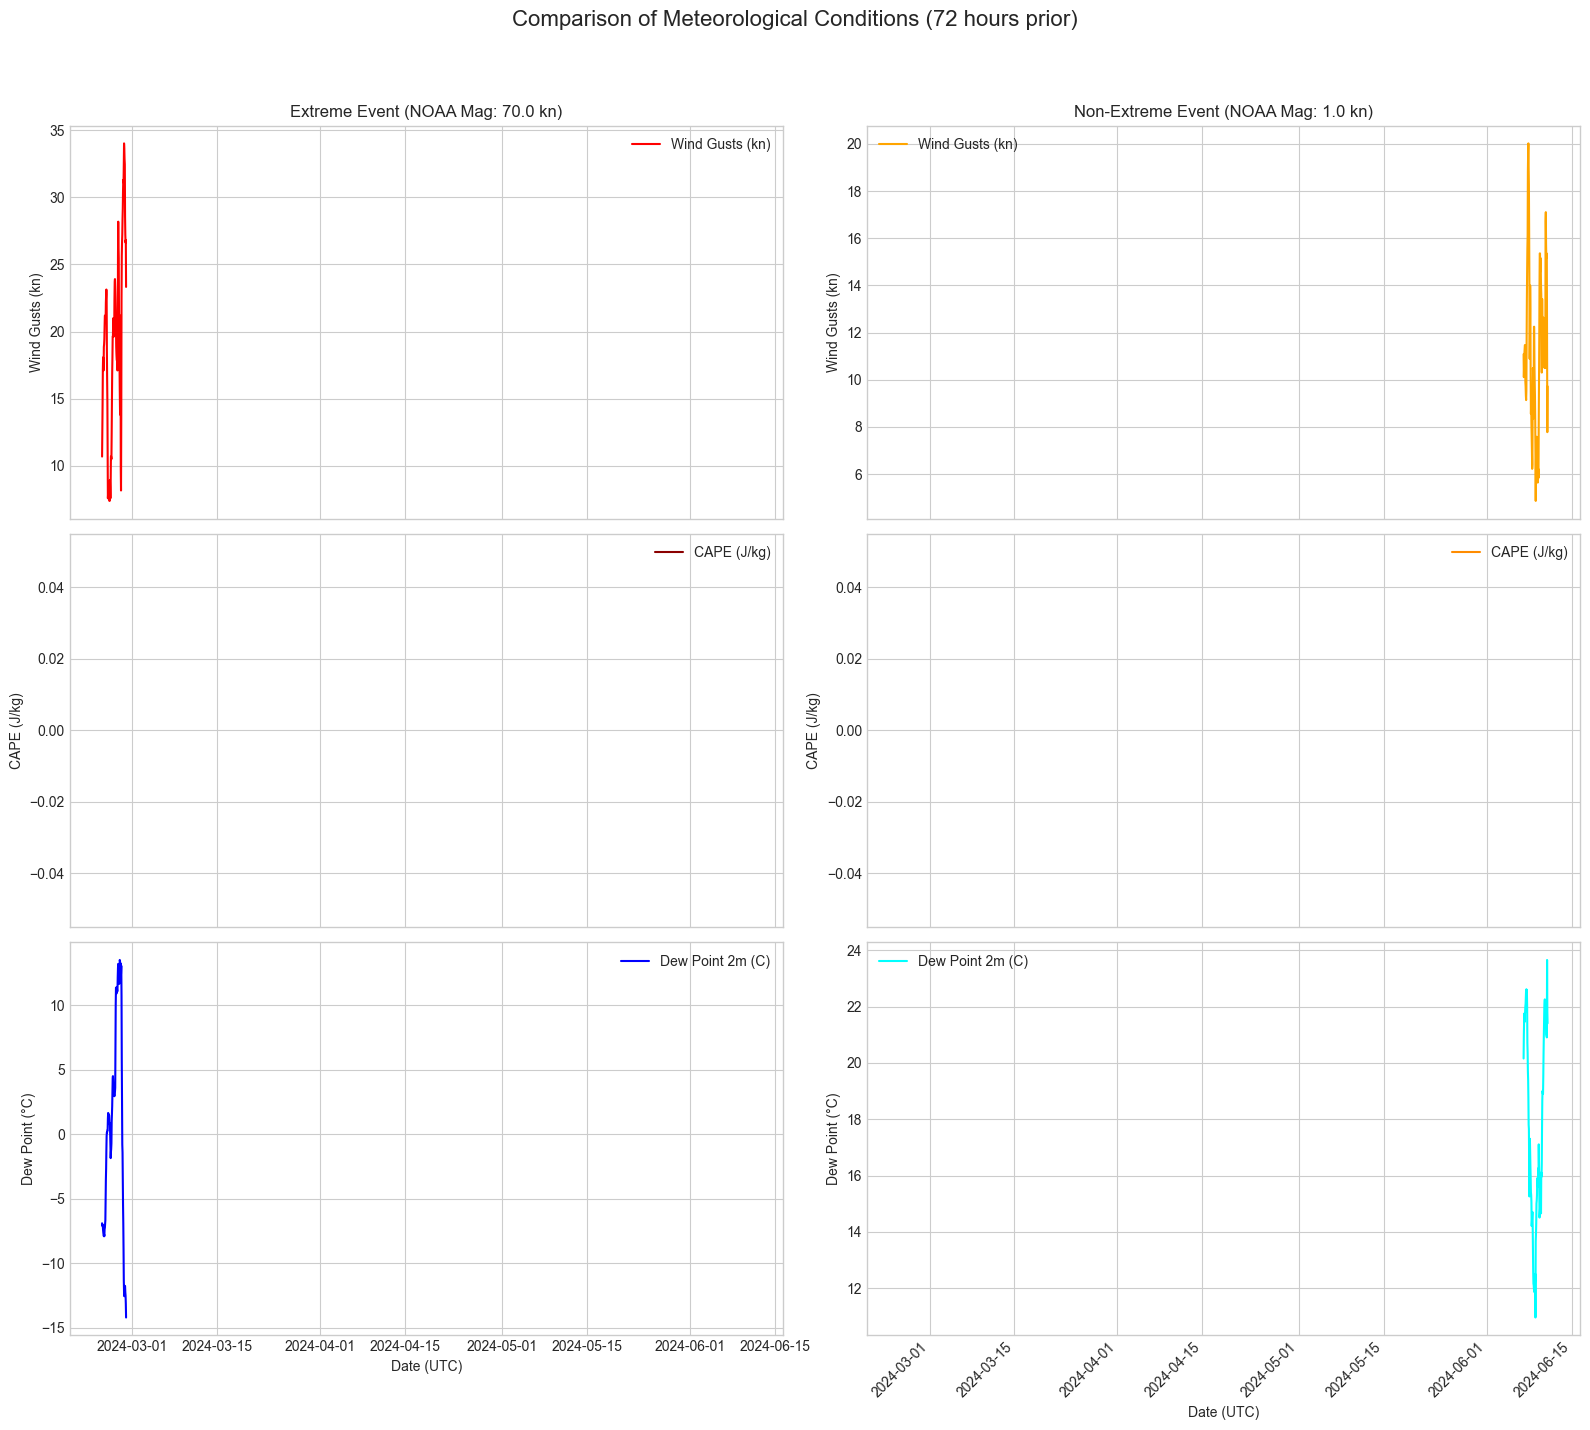


--- Next Steps ---
1. Analyze the new variables: Look for significant differences in CAPE, Lifted Index, moisture, and wind profiles between the extreme and non-extreme cases.
2. Calculate Derived Variables:
   - Lapse Rates: Calculate temperature difference between levels (e.g., T_500hPa - T_850hPa) / height difference. Steeper lapse rates indicate more instability.
   - Wind Shear: Calculate the vector difference between winds at different levels (e.g., wind at 500hPa vs. wind at surface or 850hPa). Strong shear helps organize storms.
3. Feature Engineering: Create rolling statistics (mean, max, std dev, rate of change) for these new variables over time windows (e.g., 3hr, 6hr, 12hr) leading up to the event time.
4. Re-train Model: Use these enhanced and derived features as input to your ML/DL model.
5. Consider Problem Reframing: If predicting the exact NOAA magnitude is still hard, try predicting high CAPE/Shear environments, or classifying events into broader severity categories.

In [5]:
import pandas as pd
from datetime import datetime, timedelta, timezone
import matplotlib.pyplot as plt
import openmeteo_requests
import requests_cache
from retry_requests import retry
import numpy as np

# ---------------------------
# Setup caching and Open-Meteo client (Keep as is)
# ---------------------------
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# ---------------------------
# Load NOAA Dataset (Keep as is)
# ---------------------------
# Replace 'noaa_data.csv' with the path to your NOAA dataset CSV file.
# try:
#     df = pd.read_csv("noaa_data.csv", low_memory=False) # Added low_memory=False for potential mixed types
# except FileNotFoundError:
#     print("Error: noaa_data.csv not found. Please ensure the file exists.")
#     exit()
# except Exception as e:
#     print(f"Error reading CSV: {e}")
#     exit()

# ---------------------------
# Filter for Thunderstorm Wind events (Keep as is, ensure events exist)
# ---------------------------
try:
    extreme_events = df[(df["event_type"] == "Thunderstorm Wind") & (df["magnitude"] >= 70)]
    if extreme_events.empty:
        print("Warning: No 'Thunderstorm Wind' events found with magnitude >= 70.")
        # Handle this case - maybe exit, or use a lower threshold for demonstration
        # For now, let's try a lower threshold if >= 70 fails
        extreme_events = df[(df["event_type"] == "Thunderstorm Wind") & (df["magnitude"] >= 50)]
        if extreme_events.empty:
             print("Error: No suitable extreme events found even at lower threshold.")
             exit()
        print("Using magnitude >= 50 for extreme event example.")

    extreme = extreme_events.iloc[0].to_dict()

    non_extreme_events = df[(df["event_type"] == "Thunderstorm Wind") & (df["magnitude"] <= 15) & (df['magnitude'] > 0)] # Adjusted non-extreme slightly
    if non_extreme_events.empty:
        print("Error: No suitable non-extreme 'Thunderstorm Wind' events found (magnitude 1-15).")
        exit()
    # Ensure we don't pick the exact same event if indices are reset or data is small
    non_extreme_index = min(5, len(non_extreme_events) - 1) # Pick index 5, or the last one if fewer than 6
    non_extreme = non_extreme_events.iloc[non_extreme_index].to_dict()

except IndexError:
    print("Error: Could not find enough matching events in the DataFrame. Check filtering criteria.")
    exit()
except KeyError as e:
    print(f"Error: Column {e} not found in CSV. Check column names.")
    exit()


# ---------------------------
# Helper function to parse timezone (Keep as is)
# ---------------------------
def parse_timezone(tz_str):
    """
    Parse a timezone string from NOAA dataset (e.g., "PST-8", "CST-6")
    and return a datetime.timezone object. Handles non-standard entries more robustly.
    """
    if not isinstance(tz_str, str):
        print(f"Warning: Invalid timezone format '{tz_str}'. Defaulting to UTC.")
        return timezone.utc # Default to UTC if format is unexpected

    # Try to extract offset directly if it's just like "-5" or "+10"
    try:
        offset_hours = int(tz_str)
        # Basic sanity check for realistic offsets
        if -14 <= offset_hours <= 14:
             return timezone(timedelta(hours=offset_hours))
    except ValueError:
        pass # Continue to other parsing methods if direct int conversion fails

    # Handle formats like "XXX-offset" or "XXX+offset"
    if '-' in tz_str:
        parts = tz_str.split('-')
        try:
            # Get the last part assuming it's the offset
            offset = -abs(int(parts[-1]))
            if -14 <= offset <= 14:
                 return timezone(timedelta(hours=offset))
        except (ValueError, IndexError):
             pass # Ignore if parsing fails
    elif '+' in tz_str:
         parts = tz_str.split('+')
         try:
            offset = abs(int(parts[-1]))
            if -14 <= offset <= 14:
                return timezone(timedelta(hours=offset))
         except (ValueError, IndexError):
            pass # Ignore if parsing fails

    # If all else fails or format is unrecognized (like just "CST")
    print(f"Warning: Could not parse timezone offset from '{tz_str}'. Defaulting to UTC.")
    return timezone.utc # Default to UTC

# ---------------------------
# Define an ENHANCED function to fetch weather data
# ---------------------------
def fetch_enhanced_weather_data(event):
    """
    Given an event dictionary, fetch weather data from Open-Meteo's ERA5
    reanalysis for the 72 hours prior to the event's end_date_time.
    Includes surface, instability, shear potential, and moisture variables.
    Converts local event time (using cz_timezone) to UTC.
    """
    try:
        latitude = event["latitude"]
        longitude = event["longitude"]
        end_date_time_str = event["end_date_time"]
        tz_str = event.get("cz_timezone", "UTC")

        event_tz = parse_timezone(tz_str)

        # Parse the end_date_time in local time and assign the proper timezone
        # Use errors='coerce' for robustness against potential format issues if needed, but try direct first
        end_local = datetime.strptime(end_date_time_str, '%d-%b-%y %H:%M:%S').replace(tzinfo=event_tz)

        # Convert the local time to UTC
        end_date_utc = end_local.astimezone(timezone.utc)
        # Define the start of the window (72 hours prior to the END of the event)
        start_date_utc = end_date_utc - timedelta(hours=72)

        print(f"\nFetching data for event ending:")
        print(f"  End Local: {end_local.strftime('%Y-%m-%d %H:%M:%S %Z%z')}")
        print(f"  End UTC:   {end_date_utc.strftime('%Y-%m-%d %H:%M:%S %Z')}")
        print(f"  Start UTC: {start_date_utc.strftime('%Y-%m-%d %H:%M:%S %Z')}")
        print(f"  Lat/Lon:   {latitude}, {longitude}")

        # Prepare parameters for the API request - ADDING MANY MORE VARIABLES
        params = {
            "latitude": latitude,
            "longitude": longitude,
            "start_date": start_date_utc.strftime('%Y-%m-%d'),
            "end_date": end_date_utc.strftime('%Y-%m-%d'),
            "hourly": [
                # Basic Surface Vars
                "temperature_2m", "relative_humidity_2m", "dew_point_2m",
                "apparent_temperature", "pressure_msl", "surface_pressure",
                "precipitation", "rain", "snowfall", "weather_code", "cloud_cover",
                # Surface Winds
                "wind_speed_10m", "wind_direction_10m", "wind_gusts_10m",
                # --- ENHANCED VARIABLES ---
                # Instability Indices (Crucial for thunderstorms)
                "cape",             # Convective Available Potential Energy (J/kg) - Higher means more potential energy
                "lifted_index",     # Lifted Index (K) - Negative values indicate instability
                # Moisture at different levels (Understanding vertical moisture profile)
                "relative_humidity_1000hPa", "relative_humidity_850hPa",
                "relative_humidity_700hPa", "relative_humidity_500hPa",
                # Temperature at different levels (For calculating lapse rates -> instability)
                "temperature_1000hPa", "temperature_850hPa",
                "temperature_700hPa", "temperature_500hPa",
                # Winds at different levels (For calculating shear -> storm organization/severity)
                "wind_speed_850hPa", "wind_direction_850hPa",
                "wind_speed_700hPa", "wind_direction_700hPa",
                "wind_speed_500hPa", "wind_direction_500hPa",
                 # Geopotential Height (Shows troughs/ridges which influence weather patterns)
                "geopotential_height_850hPa", "geopotential_height_500hPa"
                # Optional: Add more levels (e.g., 925hPa, 300hPa) or other vars if needed
            ],
            "wind_speed_unit": "kn", # Use knots to be closer to NOAA magnitude units
             # Specify ERA5 explicitly for potentially better data consistency
            "models": "era5"
        }

        # Fetch weather data from Open-Meteo API
        print(f"  Requesting {len(params['hourly'])} variables...")
        responses = openmeteo.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)
        response = responses[0]
        print(f"  Data received successfully.")

        # Process hourly data
        hourly = response.Hourly()

        # Create time range
        times = pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left"
        )

        data = {
            "date": times,
            "latitude": latitude, # Keep original requested lat/lon
            "longitude": longitude,
            "api_latitude": response.Latitude(),
            "api_longitude": response.Longitude()
        }

        hourly_variables = response.Hourly() # Get the hourly object once
        requested_var_names = params["hourly"]
        num_vars_api_returned = 0 # Initialize count

        # It's safer to check if VariablesLength method exists and use it
        if hasattr(hourly_variables, 'VariablesLength'):
             num_vars_api_returned = hourly_variables.VariablesLength()
             print(f"  API reported {num_vars_api_returned} variables returned.")
        else:
             # Fallback or warning if VariablesLength is not available (unlikely for recent versions)
             print("  Warning: Cannot determine exact number of variables returned by API via VariablesLength().")
             # We might have to rely on the requested length, which is less robust
             num_vars_api_returned = len(requested_var_names)


        # Iterate based on the ORDER of requested variables.
        # The API usually returns them in the same order.
        for idx, var_name in enumerate(requested_var_names):
            # Check if the index is within the bounds of what the API actually returned
            if idx < num_vars_api_returned:
                try:
                    # Access the variable data by its index 'idx'
                    variable = hourly_variables.Variables(idx) # Pass the index 'idx'
                    values = variable.ValuesAsNumpy()

                    print(f"    Processing: {var_name} (index {idx}, {len(values)} values)")

                    # Check for length consistency
                    if len(times) != len(values):
                        print(f"      *** Length mismatch for {var_name}! Expected {len(times)}, got {len(values)}. Filling with NaN. ***")
                        # Ensure the NaN array has the correct length expected by the 'times' index
                        data[var_name] = np.full(len(times), np.nan)
                    else:
                        data[var_name] = values

                except TypeError as te:
                    # Specifically catch the error you encountered
                    print(f"      *** TypeError accessing variable '{var_name}' at index {idx}: {te} ***")
                    print(f"      *** This likely indicates an issue with the library version or API response parsing. Skipping variable. ***")
                    data[var_name] = np.full(len(times), np.nan) # Fill with NaNs
                except IndexError:
                    # This shouldn't happen with the idx < num_vars_api_returned check, but for safety:
                    print(f"      *** Error: Index {idx} out of bounds unexpectedly for variable '{var_name}'. Skipping. ***")
                    data[var_name] = np.full(len(times), np.nan)
                except Exception as e:
                    # Catch any other unexpected errors during processing
                    print(f"      *** Unexpected error processing variable '{var_name}' at index {idx}: {e} ***")
                    data[var_name] = np.full(len(times), np.nan)
            else:
                # If API returned fewer variables than requested
                print(f"    Skipping: {var_name} (index {idx}) - Variable not found in API response (API returned only {num_vars_api_returned}).")
                data[var_name] = np.full(len(times), np.nan) # Fill with NaNs

        weather_df = pd.DataFrame(data)
        # Set date as index AFTER DataFrame creation and filling data
        weather_df = weather_df.set_index('date')
        return weather_df

    except Exception as e:
        print(f"Error fetching or processing data for event: {e}")
        # Print event details that caused the error
        print("Event details:", event)
        return pd.DataFrame() # Return empty DataFrame on error

# ---------------------------
# Fetch ENHANCED weather data for events
# ---------------------------
print("Fetching data for EXTREME event...")
weather_extreme_enhanced = fetch_enhanced_weather_data(extreme)

print("\nFetching data for NON-EXTREME event...")
weather_non_extreme_enhanced = fetch_enhanced_weather_data(non_extreme)

# ---------------------------
# Basic Data Checks
# ---------------------------
print("\n--- Data Check ---")
print(f"Extreme event data shape: {weather_extreme_enhanced.shape}")
print(f"Non-extreme event data shape: {weather_non_extreme_enhanced.shape}")

# Check if data was fetched successfully
if weather_extreme_enhanced.empty or weather_non_extreme_enhanced.empty:
    print("\nError: Data fetching failed for one or both events. Cannot proceed with plotting.")
else:
    print("\nColumns available:", weather_extreme_enhanced.columns.tolist())
    print("\nSample extreme data head:")
    print(weather_extreme_enhanced.head())

    # ---------------------------
    # Plotting Examples (Include some new variables)
    # ---------------------------
    print("\nGenerating plots...")
    plt.style.use('seaborn-v0_8-whitegrid') # Use a nice style

    fig, axes = plt.subplots(3, 2, figsize=(16, 15), sharex=True) # 3 rows, 2 columns

    # --- Row 1: Wind Gusts ---
    axes[0, 0].plot(weather_extreme_enhanced.index, weather_extreme_enhanced["wind_gusts_10m"], label="Wind Gusts (kn)", color='red')
    axes[0, 0].set_title(f"Extreme Event (NOAA Mag: {extreme.get('magnitude', 'N/A')} kn)")
    axes[0, 0].set_ylabel("Wind Gusts (kn)")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(weather_non_extreme_enhanced.index, weather_non_extreme_enhanced["wind_gusts_10m"], label="Wind Gusts (kn)", color='orange')
    axes[0, 1].set_title(f"Non-Extreme Event (NOAA Mag: {non_extreme.get('magnitude', 'N/A')} kn)")
    axes[0, 1].set_ylabel("Wind Gusts (kn)")
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # --- Row 2: CAPE (Instability) ---
    axes[1, 0].plot(weather_extreme_enhanced.index, weather_extreme_enhanced["cape"], label="CAPE (J/kg)", color='darkred')
    axes[1, 0].set_ylabel("CAPE (J/kg)")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(weather_non_extreme_enhanced.index, weather_non_extreme_enhanced["cape"], label="CAPE (J/kg)", color='darkorange')
    axes[1, 1].set_ylabel("CAPE (J/kg)")
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    # --- Row 3: Dew Point (Surface Moisture) ---
    axes[2, 0].plot(weather_extreme_enhanced.index, weather_extreme_enhanced["dew_point_2m"], label="Dew Point 2m (C)", color='blue')
    axes[2, 0].set_ylabel("Dew Point (°C)")
    axes[2, 0].set_xlabel("Date (UTC)")
    axes[2, 0].legend()
    axes[2, 0].grid(True)

    axes[2, 1].plot(weather_non_extreme_enhanced.index, weather_non_extreme_enhanced["dew_point_2m"], label="Dew Point 2m (C)", color='cyan')
    axes[2, 1].set_ylabel("Dew Point (°C)")
    axes[2, 1].set_xlabel("Date (UTC)")
    axes[2, 1].legend()
    axes[2, 1].grid(True)

    # Improve layout and display
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels on the last row
    fig.suptitle("Comparison of Meteorological Conditions (72 hours prior)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

    print("\n--- Next Steps ---")
    print("1. Analyze the new variables: Look for significant differences in CAPE, Lifted Index, moisture, and wind profiles between the extreme and non-extreme cases.")
    print("2. Calculate Derived Variables:")
    print("   - Lapse Rates: Calculate temperature difference between levels (e.g., T_500hPa - T_850hPa) / height difference. Steeper lapse rates indicate more instability.")
    print("   - Wind Shear: Calculate the vector difference between winds at different levels (e.g., wind at 500hPa vs. wind at surface or 850hPa). Strong shear helps organize storms.")
    print("3. Feature Engineering: Create rolling statistics (mean, max, std dev, rate of change) for these new variables over time windows (e.g., 3hr, 6hr, 12hr) leading up to the event time.")
    print("4. Re-train Model: Use these enhanced and derived features as input to your ML/DL model.")
    print("5. Consider Problem Reframing: If predicting the exact NOAA magnitude is still hard, try predicting high CAPE/Shear environments, or classifying events into broader severity categories.")

# Example of calculating a derived variable (Lapse Rate Estimate)
if not weather_extreme_enhanced.empty and 'temperature_850hPa' in weather_extreme_enhanced.columns and 'temperature_500hPa' in weather_extreme_enhanced.columns:
     # Note: This is a simplified lapse rate. Accurate calculation needs geopotential height.
     # Higher positive values indicate steeper (more unstable) lapse rates.
     weather_extreme_enhanced['lapse_rate_850_500'] = weather_extreme_enhanced['temperature_850hPa'] - weather_extreme_enhanced['temperature_500hPa']
     print("\nAdded 'lapse_rate_850_500' estimate to extreme data.")
     # You would do the same for non_extreme data and then plot or use this feature.

In [170]:
from datetime import datetime
import matplotlib.pyplot as plt
from meteostat import Point, Hourly
import pandas as pd
import numpy as np
def fetch_weather_data(latitude, longitude, start_date, end_date):
    """
    Fetch historical weather data for a specific location and date range.
    """
    # Create a Point for the location
    location = Point(latitude, longitude)
    
    # Set the time period
    start = datetime.strptime(start_date, '%Y-%m-%d')
    end = datetime.strptime(end_date, '%Y-%m-%d')
    
    # Fetch hourly data
    data = Hourly(location, start, end)
    data = data.fetch()
    
    return data
# Coordinates for the location (e.g., Chandler, Arizona)
latitude = 33.3062
longitude = -111.8413

# Define date ranges for analysis
start_date_extreme = '2024-02-01'
end_date_extreme = '2024-02-28'

start_date_non_extreme = '2024-03-01'
end_date_non_extreme = '2024-03-31'

# Fetch weather data
weather_extreme = fetch_weather_data(latitude, longitude, start_date_extreme, end_date_extreme)
weather_non_extreme = fetch_weather_data(latitude, longitude, start_date_non_extreme, end_date_non_extreme)
# Calculate the 90th percentile for wind gusts
threshold_extreme = np.percentile(weather_extreme['wsg10'], 90)
threshold_non_extreme = np.percentile(weather_non_extreme['wsg10'], 90)

# Categorize events
weather_extreme['event_type'] = np.where(weather_extreme['wsg10'] >= threshold_extreme, 'Extreme', 'Non-Extreme')
weather_non_extreme['event_type'] = np.where(weather_non_extreme['wsg10'] >= threshold_non_extreme, 'Extreme', 'Non-Extreme')
plt.figure(figsize=(14, 6))

# Plot extreme event wind speed
plt.subplot(1, 2, 1)
plt.plot(weather_extreme.index, weather_extreme['wsg10'], label='Wind Speed', color='blue')
plt.axhline(y=threshold_extreme, color='red', linestyle='--', label='90th Percentile Threshold')
plt.fill_between(weather_extreme.index, weather_extreme['wsg10'], threshold_extreme, where=(weather_extreme['wsg10'] >= threshold_extreme), color='red', alpha=0.3, label='Extreme Events')
plt.title("Extreme Thunderstorm Wind Event")
plt.xlabel("Date")
plt.ylabel("Wind Speed (m/s)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

# Plot non-extreme event wind speed
plt.subplot(1, 2, 2)
plt.plot(weather_non_extreme.index, weather_non_extreme['wsg10'], label='Wind Speed', color='orange')
plt.axhline(y=threshold_non_extreme, color='green', linestyle='--', label='90th Percentile Threshold')
plt.fill_between(weather_non_extreme.index, weather_non_extreme['wsg10'], threshold_non_extreme, where=(weather_non_extreme['wsg10'] >= threshold_non_extreme), color='green', alpha=0.3, label='Extreme Events')
plt.title("Non-Extreme Thunderstorm Wind Event")
plt.xlabel("Date")
plt.ylabel("Wind Speed (m/s)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


KeyError: 'wsg10'

In [59]:
for i in df.isna().sum().sort_values(ascending=False).items():
    if i[1]/df.shape[0] > 0.4:
        print(i[0], i[1])
        df.drop(columns=[i[0]], inplace=True)

lon2 1157009
lat2 1157009
range 1112336
azimuth 1112336
end_azimuth 1111116
begin_azimuth 1098179


In [58]:
945887/df.shape[0]

0.39145102904739815

In [66]:
df = df[df["year"] > 2007]

In [168]:
%pip install meteostat


Note: you may need to restart the kernel to use updated packages.


In [169]:
  from meteostat import Stations, Hourly
  from datetime import datetime

  # Set time period
  start = datetime(2024, 2, 1)
  end = datetime(2024, 2, 28)

  # Get nearby weather stations
  stations = Stations()
  stations = stations.nearby(37.51, -122.27)  # Example coordinates
  station = stations.fetch(1)

  # Fetch hourly data
  data = Hourly(station, start, end)
  data = data.fetch()

  # Display data
  print(data)


                     temp  dwpt  rhum  prcp  snow   wdir  wspd  wpgt    pres  \
time                                                                           
2024-02-01 00:00:00  13.1  11.7  91.0   2.1   NaN  139.0  35.6   NaN  1003.1   
2024-02-01 01:00:00  12.7  11.4  92.0   1.9   NaN  143.0  39.2   NaN  1002.9   
2024-02-01 02:00:00  12.4  11.3  93.0   4.0   NaN  145.0  38.5   NaN  1002.8   
2024-02-01 03:00:00  12.4  11.3  93.0   3.5   NaN  130.0  27.0   NaN  1002.2   
2024-02-01 04:00:00  12.5  11.4  93.0   2.0   NaN  145.0  29.2   NaN  1001.9   
...                   ...   ...   ...   ...   ...    ...   ...   ...     ...   
2024-02-27 20:00:00  14.0   0.9  41.0   0.0   NaN  280.0   5.4   NaN  1019.0   
2024-02-27 21:00:00  15.0   1.8  41.0   0.0   NaN  310.0   9.4   NaN  1019.0   
2024-02-27 22:00:00  16.0   2.0  39.0   0.0   NaN  330.0  14.8   NaN  1018.0   
2024-02-27 23:00:00  17.0   1.0  34.0   0.0   NaN  310.0  13.0   NaN  1018.0   
2024-02-28 00:00:00  13.4   3.2  50.0   

In [5]:
import pandas as pd



import pandas as pd
import numpy as np

# Function to convert damage strings (e.g., "10.00K", "10.00M") to a numeric value
def convert_damage(damage_str):
    try:
        if pd.isnull(damage_str):
            return 0.0
        damage_str = str(damage_str).strip()
        if damage_str.endswith('K'):
            return float(damage_str[:-1]) * 1e3
        elif damage_str.endswith('M'):
            return float(damage_str[:-1]) * 1e6
        else:
            return float(damage_str)
    except Exception:
        return 0.0

# Function to categorize an event as extreme (1) or non-extreme (0)
def categorize_extreme(row):
    # Get the event type and ensure no extra spaces
    event_type = str(row.get('event_type', '')).strip()
    
    # Convert damages to numeric values
    damage_property = convert_damage(row.get('damage_property', '0.00K'))
    damage_crops = convert_damage(row.get('damage_crops', '0.00K'))
    total_damage = damage_property + damage_crops
    
    # Sum injuries and deaths from direct and indirect counts
    total_injuries = (row.get('injuries_direct', 0) or 0) + (row.get('injuries_indirect', 0) or 0)
    total_deaths = (row.get('deaths_direct', 0) or 0) + (row.get('deaths_indirect', 0) or 0)
    
    # Set default thresholds (adjust these based on your domain knowledge)
    damage_threshold = 100000       # Example: $100K damage threshold
    injury_threshold = 20           # Example: 20 or more injuries
    death_threshold = 5             # Example: 5 or more deaths
    wind_speed_threshold = 50       # Wind speed in knots for extreme wind events
    hail_size_threshold = 1.5       # Hail size in inches considered extreme
    
    # Overall impact: if damage, injuries, or deaths exceed thresholds, mark as extreme.
    if total_damage >= damage_threshold or total_injuries >= injury_threshold or total_deaths >= death_threshold:
        return 1
    
    # Specific rules per event type
    if event_type == 'Tornado':
        # Use the Enhanced Fujita Scale: EF2 or higher is considered extreme.
        tor_scale = str(row.get('tor_f_scale', 'EF0')).strip()
        try:
            scale_value = int(tor_scale.replace('EF', ''))
        except Exception:
            scale_value = 0
        if scale_value >= 2:
            return 1

    if event_type in ['Thunderstorm Wind', 'High Wind', 'Strong Wind', 'Marine Thunderstorm Wind']:
        # For wind events, use the magnitude (assumed to be in knots)
        try:
            magnitude = float(row.get('magnitude', 0))
        except Exception:
            magnitude = 0
        if magnitude >= wind_speed_threshold:
            return 1

    if event_type == 'Hail':
        # For hail events, use the magnitude (assumed to be in inches)
        try:
            magnitude = float(row.get('magnitude', 0))
        except Exception:
            magnitude = 0
        if magnitude >= hail_size_threshold:
            return 1

    if event_type in ['Flash Flood', 'Flood', 'Coastal Flood']:
        # Flood events may be extreme if they cause high damage (already checked above) 
        if total_damage >= damage_threshold:
            return 1

    if event_type in ['Heavy Rain', 'Excessive Heat', 'Heat']:
        # These events may be extreme if they result in significant injuries or damage.
        if total_injuries >= injury_threshold or total_damage >= damage_threshold:
            return 1

    if event_type in ['Winter Storm', 'Winter Weather', 'Blizzard']:
        # Winter events are flagged based on impact
        if total_damage >= damage_threshold or total_injuries >= injury_threshold:
            return 1

    # Additional event-specific rules can be added here

    # If none of the conditions are met, mark as non-extreme.
    return 0


df.columns = df.columns.str.strip().str.lower()  # e.g., converting "Event_Type" to "event_type"

# Apply the categorization function to each row in the DataFrame
df['extreme'] = df.apply(categorize_extreme, axis=1)

#

In [28]:
extreme = df[(df["event_type"] == "Flash Flood") & (df["begin_yearmonth"] == 201508) & (df["extreme"] == 1) ]

In [27]:
non_extreme = df[(df["event_type"] == "Flash Flood") & (df["begin_yearmonth"] == 201508) & (df["extreme"] == 0)]

In [47]:


import pandas as pd
from datetime import datetime
import pytz

# Mapping of timezone abbreviations to UTC offsets
timezone_offsets = {
    'CST-6': -6,
    'EST-5': -5,
    'MST-7': -7,
    'PST-8': -8,
    'AST-4': -4,
    'HST-10': -10,
    'AKST-9': -9,
    'SST-11': -11,
    'GST10': 10
}

# Function to convert local time to UTC
def convert_to_utc(local_time_str, timezone):
    local_time = datetime.strptime(local_time_str, '%d-%b-%y %H:%M:%S')
    offset = timezone_offsets.get(timezone, 0)
    local_time = local_time.replace(tzinfo=pytz.FixedOffset(offset * 60))
    utc_time = local_time.astimezone(pytz.utc)
    return utc_time

# Apply the function to the begin_date_time and end_date_time columns
non_extreme['begin_date_time_utc'] = non_extreme.apply(lambda row: convert_to_utc(row['begin_date_time'], row['cz_timezone']), axis=1)
non_extreme['end_date_time_utc'] = non_extreme.apply(lambda row: convert_to_utc(row['end_date_time'], row['cz_timezone']), axis=1)

# Split the datetime objects into separate date and time columns
non_extreme['begin_date_utc'] = non_extreme['begin_date_time_utc'].dt.date
non_extreme['begin_time_utc'] = non_extreme['begin_date_time_utc'].dt.time
non_extreme['end_date_utc'] = non_extreme['end_date_time_utc'].dt.date
non_extreme['end_time_utc'] = non_extreme['end_date_time_utc'].dt.time

# Drop the intermediate UTC datetime columns
non_extreme.drop(columns=['begin_date_time_utc', 'end_date_time_utc'], inplace=True)


C:\Users\naman\AppData\Local\Temp\ipykernel_18132\311165355.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_extreme['begin_date_time_utc'] = non_extreme.apply(lambda row: convert_to_utc(row['begin_date_time'], row['cz_timezone']), axis=1)
C:\Users\naman\AppData\Local\Temp\ipykernel_18132\311165355.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_extreme['end_date_time_utc'] = non_extreme.apply(lambda row: convert_to_utc(row['end_date_time'], row['cz_timezone']), axis=1)
C:\Users\naman\AppDa

In [40]:
row.index

Index(['begin_yearmonth', 'begin_day', 'begin_time', 'end_yearmonth',
       'end_day', 'end_time', 'episode_id_x', 'event_id', 'state',
       'state_fips', 'year', 'month_name', 'event_type', 'cz_type', 'cz_fips',
       'cz_name', 'wfo', 'begin_date_time', 'cz_timezone', 'end_date_time',
       'injuries_direct', 'injuries_indirect', 'deaths_direct',
       'deaths_indirect', 'damage_property', 'damage_crops', 'source',
       'magnitude', 'magnitude_type', 'flood_cause', 'category', 'tor_f_scale',
       'tor_length', 'tor_width', 'tor_other_wfo', 'tor_other_cz_state',
       'tor_other_cz_fips', 'tor_other_cz_name', 'begin_range',
       'begin_azimuth', 'begin_location', 'end_range', 'end_azimuth',
       'end_location', 'begin_lat', 'begin_lon', 'end_lat', 'end_lon',
       'episode_narrative', 'event_narrative', 'data_source', 'yearmonth',
       'episode_id_y', 'location_index', 'range', 'azimuth', 'location',
       'latitude', 'longitude', 'lat2', 'lon2', 'fat_yearmonth', 'f

In [41]:
import openmeteo_requests
import requests_cache
from retry_requests import retry
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)
row = extreme.iloc[0]
params = {
            "latitude": row["begin_lat"],
            "longitude": row["begin_lon"],
            "start_date": row["begin_date_utc"],
            "end_date": row["end_date_utc"],
            "hourly": [
                "temperature_2m",
                "relative_humidity_2m",
                "dew_point_2m",
                "apparent_temperature",
                "precipitation",
                "rain",
                "snowfall",
                "snow_depth",
                "weather_code",
                "pressure_msl",
                "surface_pressure",
                "cloud_cover",
                "wind_speed_10m",
                "wind_direction_10m",
                "wind_gusts_10m",
                "soil_temperature_0_to_7cm",
                "soil_moisture_0_to_7cm"
            ]
        }
        
       
responses = openmeteo.weather_api(
    "https://archive-api.open-meteo.com/v1/archive",
    params=params
)
response = responses[0]

# Process hourly data
hourly = response.Hourly()
data = {
    "date": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ),
    "latitude": row["begin_lat"],
    "longitude": row["begin_lon"]
}

# Add all weather variables
for idx, var in enumerate(params["hourly"]):
    data[var] = hourly.Variables(idx).ValuesAsNumpy()


In [44]:
data["precipitation"]

array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.4, 0. , 0. , 0.5],
      dtype=float32)

In [46]:
row.index

Index(['begin_yearmonth', 'begin_day', 'begin_time', 'end_yearmonth',
       'end_day', 'end_time', 'episode_id_x', 'event_id', 'state',
       'state_fips', 'year', 'month_name', 'event_type', 'cz_type', 'cz_fips',
       'cz_name', 'wfo', 'begin_date_time', 'cz_timezone', 'end_date_time',
       'injuries_direct', 'injuries_indirect', 'deaths_direct',
       'deaths_indirect', 'damage_property', 'damage_crops', 'source',
       'magnitude', 'magnitude_type', 'flood_cause', 'category', 'tor_f_scale',
       'tor_length', 'tor_width', 'tor_other_wfo', 'tor_other_cz_state',
       'tor_other_cz_fips', 'tor_other_cz_name', 'begin_range',
       'begin_azimuth', 'begin_location', 'end_range', 'end_azimuth',
       'end_location', 'begin_lat', 'begin_lon', 'end_lat', 'end_lon',
       'episode_narrative', 'event_narrative', 'data_source', 'yearmonth',
       'episode_id_y', 'location_index', 'range', 'azimuth', 'location',
       'latitude', 'longitude', 'lat2', 'lon2', 'fat_yearmonth', 'f

In [48]:
import openmeteo_requests
import requests_cache
from retry_requests import retry
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)
row = non_extreme.iloc[0]
params = {
            "latitude": row["begin_lat"],
            "longitude": row["begin_lon"],
            "start_date": row["begin_date_utc"],
            "end_date": row["end_date_utc"],
            "hourly": [
                "temperature_2m",
                "relative_humidity_2m",
                "dew_point_2m",
                "apparent_temperature",
                "precipitation",
                "rain",
                "snowfall",
                "snow_depth",
                "weather_code",
                "pressure_msl",
                "surface_pressure",
                "cloud_cover",
                "wind_speed_10m",
                "wind_direction_10m",
                "wind_gusts_10m",
                "soil_temperature_0_to_7cm",
                "soil_moisture_0_to_7cm"
            ]
        }
        
       
responses = openmeteo.weather_api(
    "https://archive-api.open-meteo.com/v1/archive",
    params=params
)
response = responses[0]

# Process hourly data
hourly = response.Hourly()
data = {
    "date": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ),
    "latitude": row["begin_lat"],
    "longitude": row["begin_lon"]
}

# Add all weather variables
for idx, var in enumerate(params["hourly"]):
    data[var] = hourly.Variables(idx).ValuesAsNumpy()


In [50]:
data["precipitation"]

array([0.5, 1. , 0.9, 0.7, 0.5, 0.2, 0. , 1.2, 1.1, 0.6, 0.2, 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
      dtype=float32)